In [20]:
import sys
sys.path.insert(0, '..')
from dependencies import *


envelopes_log = eelbrain.load.unpickle(PROCESSED_PREDICTOR_DIR / f'~processed_envelopes-log.pickle')
subject_model_predictors = eelbrain.load.unpickle(PREDICTOR_DIR / f'~concatenated_predictors.pickle')
durations = get_durations(envelopes_log)
models = get_models()

In [23]:
# Loop over all models
for model in models:
    print(f'\nProcessing universal TRF for model: {model}')
    trf_list = []

    # Collect TRFs for all subjects for this model
    for subject in SUBJECTS:
        trf = eelbrain.load.unpickle(TRF_DIR / subject / f'{subject} {model}.pickle').h_scaled
        trf_list.append(trf[0])

    # Combine and average across subjects
    universal_trf = eelbrain.combine(trf_list).mean('case')

    # Save universal TRF for this model
    eelbrain.save.pickle(universal_trf, TRF_DIR / f'universal-trf-{model}.pickle')

    print(f'Saved universal TRF for model {model}')


Processing universal TRF for model: envelope_log
Saved universal TRF for model envelope_log

Processing universal TRF for model: envelope_onset
Saved universal TRF for model envelope_onset


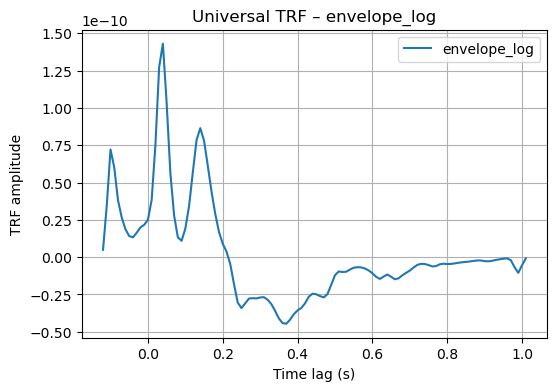

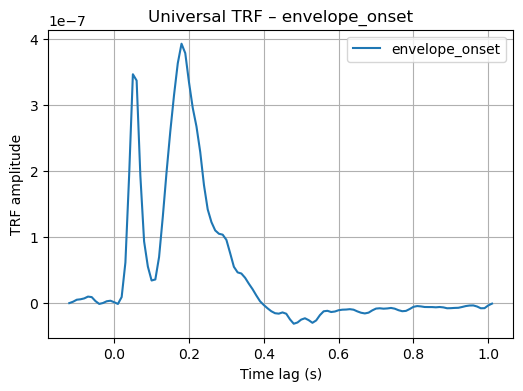

In [24]:
for model in models:
    # Load the universal TRF
    trf = eelbrain.load.unpickle(TRF_DIR / f'universal-trf-{model}.pickle')

    # h_scaled is sensor × time × predictors
    # Average across sensors
    trf_mean = trf.mean('sensor')

    # If you have multiple predictors (like 8-band), you can also average across predictors:
    if 'predictor' in trf_mean.dims:
        trf_mean = trf_mean.mean('predictor')

    # Plot the TRF as a function of time
    plt.figure(figsize=(6,4))
    plt.plot(trf_mean.time, trf_mean.x, label=f'{model}')
    plt.xlabel('Time lag (s)')
    plt.ylabel('TRF amplitude')
    plt.title(f'Universal TRF – {model}')
    plt.grid(True)
    plt.legend()
    plt.show()

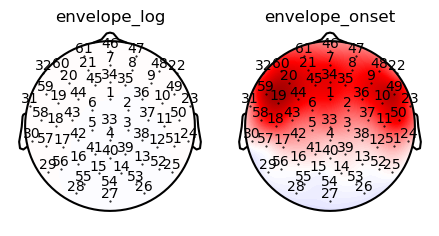

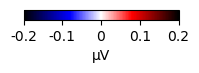

In [25]:
# Plot the TRFs
# Define your models and load universal TRFs
 # replace with your actual model names

universal_trfs = []
for model in models:
    trf = eelbrain.load.unpickle(TRF_DIR / f'universal-trf-{model}.pickle')
    universal_trfs.append(trf)

# Plot the topography of each universal TRF
# Assuming you want to use the 'proportion_explained' or the TRF amplitude
titles = [f'{model}' for model in models]

# If you want the TRF amplitude at peak latency, you can select it like:
# e.g., h_scaled.mean('time') or just pass h_scaled
trf_ndvars = [trf for trf in universal_trfs]

p = eelbrain.plot.Topomap(
    trf_ndvars,
    sensorlabels='name',
    clip='circle',
    rows=1,      # one row, three columns
    axtitle=titles
)

p_cb = p.plot_colorbar(width=.1, w=2)


# Deprecated code

In [19]:
# AVERAGE OF ALL TRFS

model = 'envelope_log'
trf_list = []

'''
max_subject = None
max_n = 0
for subject in SUBJECTS:
    boost_result = eelbrain.load.unpickle(TRF_DIR / subject / f'{subject} {model}.pickle')
    trf = boost_result.h_scaled
    n = len(boost_result.h_scaled.sensor)

    if n > max_n:
        max_n = n
        max_subject = subject

ref_boost_result = eelbrain.load.unpickle(TRF_DIR / max_subject / f'{max_subject} {model}.pickle')
ref_sensors = ref_boost_result.h_scaled.sensor
'''

for subject in SUBJECTS:
    trf = eelbrain.load.unpickle(TRF_DIR / subject / f'{subject} {model}.pickle').h_scaled
    print(trf)
    #trf_interpolated = trf.interpolate(sensor=ref_sensors)
    trf_list.append(trf)

universal_trf = eelbrain.combine(trf_list).mean('case')
eelbrain.save.pickle(universal_trf, TRF_DIR / 'universal-trf-average.pickle')
#universal_trf = sum(trf_list) / len(trf_list)

<NDVar 'envelope_onset': 61 sensor, 114 time>
<NDVar 'envelope_onset': 61 sensor, 114 time>
<NDVar 'envelope_onset': 61 sensor, 114 time>
<NDVar 'envelope_onset': 61 sensor, 114 time>
<NDVar 'envelope_onset': 61 sensor, 114 time>
<NDVar 'envelope_onset': 61 sensor, 114 time>
<NDVar 'envelope_onset': 61 sensor, 114 time>
<NDVar 'envelope_onset': 61 sensor, 114 time>
<NDVar 'envelope_onset': 61 sensor, 114 time>
<NDVar 'envelope_onset': 61 sensor, 114 time>
<NDVar 'envelope_onset': 61 sensor, 114 time>
<NDVar 'envelope_onset': 61 sensor, 114 time>
<NDVar 'envelope_onset': 61 sensor, 114 time>
<NDVar 'envelope_onset': 61 sensor, 114 time>
<NDVar 'envelope_onset': 61 sensor, 114 time>
<NDVar 'envelope_onset': 61 sensor, 114 time>
<NDVar 'envelope_onset': 61 sensor, 114 time>
<NDVar 'envelope_onset': 61 sensor, 114 time>
<NDVar 'envelope_onset': 61 sensor, 114 time>
<NDVar 'envelope_onset': 61 sensor, 114 time>
<NDVar 'envelope_onset': 61 sensor, 114 time>
<NDVar 'envelope_onset': 61 sensor